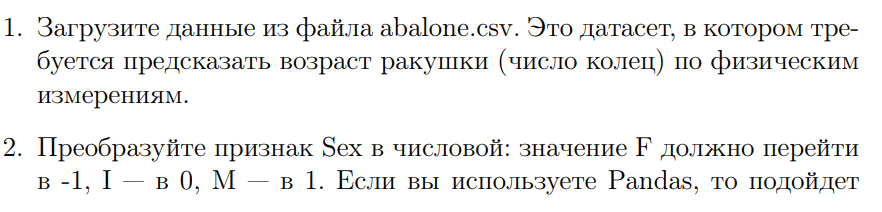
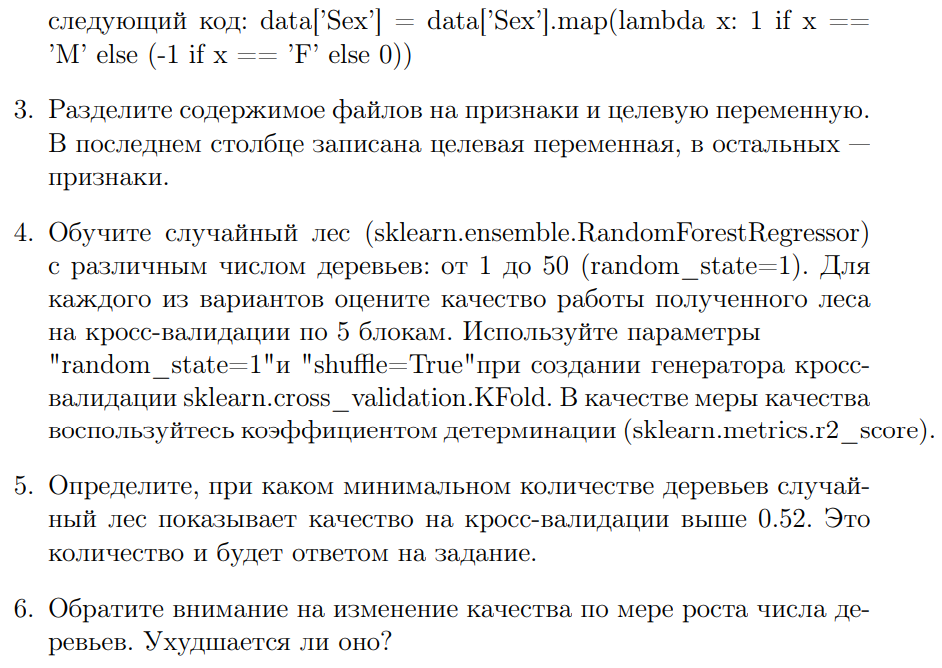

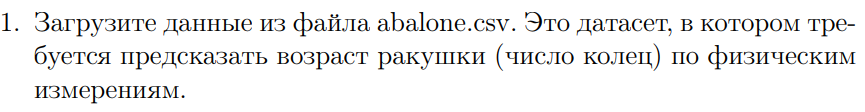

In [11]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('abalone_csv.csv', index_col=False, decimal=',')

# Удаляем столбцы, которые полностью NaN
df = df.dropna(axis=1, how='all')


print(df.head())

  Sex  Length  Diameter  Height  Whole_weight  Shucked_weight  Viscera_weight  \
0   M   0.455     0.365   0.095        0.5140          0.2245          0.1010   
1   M   0.350     0.265   0.090        0.2255          0.0995          0.0485   
2   F   0.530     0.420   0.135        0.6770          0.2565          0.1415   
3   M   0.440     0.365   0.125        0.5160          0.2155          0.1140   
4   I   0.330     0.255   0.080        0.2050          0.0895          0.0395   

   Shell_weight  Class_number_of_rings  
0         0.150                     15  
1         0.070                      7  
2         0.210                      9  
3         0.155                     10  
4         0.055                      7  


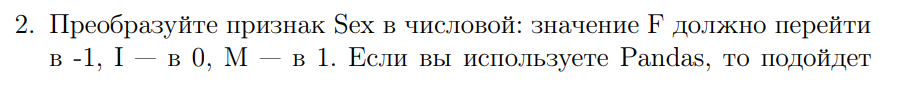
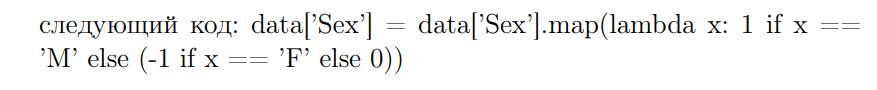

In [12]:
# Преобразуем Sex
df['Sex'] = df['Sex'].map(lambda x: 1 if x == 'M' else (-1 if x == 'F' else 0))



print("Распределение Sex после кодирования:")
print(df['Sex'].value_counts().to_string())

Распределение Sex после кодирования:
Sex
 1    1528
 0    1342
-1    1307


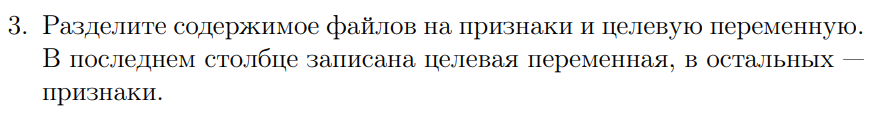

In [13]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

feature_names = X.columns.tolist()

print(y.describe().to_string())

count    4177.000000
mean        9.933684
std         3.224169
min         1.000000
25%         8.000000
50%         9.000000
75%        11.000000
max        29.000000


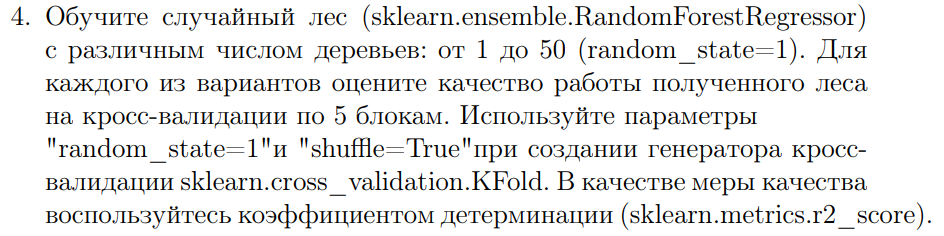

In [14]:
# Оцениваем качество для разного числа деревьев (random_state=1)
n_trees_range = range(1, 51)
cv_scores = []

kfold = KFold(n_splits=3, shuffle=True, random_state=1)

for n_trees in n_trees_range:
    rf = RandomForestRegressor(
        n_estimators=n_trees,
        random_state=1,
        n_jobs=-1
    )
    # cross_val_score с KFold
    scores = cross_val_score(
        rf, X, y,
        cv=kfold,
        scoring='r2'
    )
    cv_scores.append(scores.mean())

print("Оценка R² для разного числа деревьев:")
for n, score in enumerate(cv_scores[:10], 1):
    print(f"n_estimators={n:2d}: R² = {score:.4f}")
print("...")
for n, score in enumerate(cv_scores[-5:], len(cv_scores)-4):
    print(f"n_estimators={n:2d}: R² = {score:.4f}")

Оценка R² для разного числа деревьев:
n_estimators= 1: R² = 0.0862
n_estimators= 2: R² = 0.3107
n_estimators= 3: R² = 0.3832
n_estimators= 4: R² = 0.4229
n_estimators= 5: R² = 0.4483
n_estimators= 6: R² = 0.4651
n_estimators= 7: R² = 0.4779
n_estimators= 8: R² = 0.4853
n_estimators= 9: R² = 0.4928
n_estimators=10: R² = 0.4983
...
n_estimators=46: R² = 0.5295
n_estimators=47: R² = 0.5291
n_estimators=48: R² = 0.5289
n_estimators=49: R² = 0.5290
n_estimators=50: R² = 0.5293


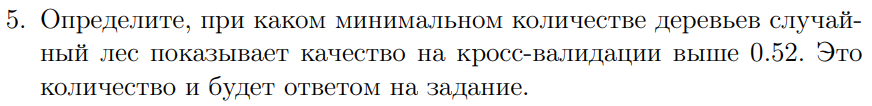

In [15]:
# Найти при скольких деревьях R² > 0.52
threshold = 0.52
best_n_estimators = None

for n, score in enumerate(cv_scores, 1):
    if score > threshold:
        best_n_estimators = n
        break

print(f"Минимальное число деревьев с R² > {threshold}: {best_n_estimators}")
print(f"R² при {best_n_estimators} деревьях: {cv_scores[best_n_estimators-1]:.4f}")

Минимальное число деревьев с R² > 0.52: 21
R² при 21 деревьях: 0.5209


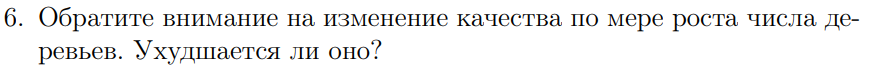

In [ ]:
print("Качество R² по мере роста числа деревьев:\n")
for n, score in enumerate(cv_scores, 1):
    marker = ' ← > 0.52' if score > 0.52 else ''
    print(f"n={n:2d}: {score:.4f}{marker}")
    
# Проверяем монотонность
max_score = max(cv_scores)
max_n = cv_scores.index(max_score) + 1

print(f"Максимальный R²: {max_score:.4f} при n_estimators={max_n}")
print(f"\nПоследний результат (50 деревьев): {cv_scores[-1]:.4f}")

if cv_scores[-1] < max_score:
    print(f"\nКачество УХУДШАЕТСЯ при дальнейшем увеличении деревьев")
    print(f"  Падение: {max_score - cv_scores[-1]:.4f}")
else:
    print(f"\nКачество НЕ ухудшается, продолжает расти или стабилизируется")

Качество R² по мере роста числа деревьев:

n= 1: 0.0862
n= 2: 0.3107
n= 3: 0.3832
n= 4: 0.4229
n= 5: 0.4483
n= 6: 0.4651
n= 7: 0.4779
n= 8: 0.4853
n= 9: 0.4928
n=10: 0.4983
n=11: 0.5058
n=12: 0.5093
n=13: 0.5112
n=14: 0.5128
n=15: 0.5118
n=16: 0.5132
n=17: 0.5149
n=18: 0.5164
n=19: 0.5179
n=20: 0.5193
n=21: 0.5209 ← > 0.52
n=22: 0.5217 ← > 0.52
n=23: 0.5219 ← > 0.52
n=24: 0.5223 ← > 0.52
n=25: 0.5219 ← > 0.52
n=26: 0.5236 ← > 0.52
n=27: 0.5256 ← > 0.52
n=28: 0.5274 ← > 0.52
n=29: 0.5278 ← > 0.52
n=30: 0.5284 ← > 0.52
n=31: 0.5279 ← > 0.52
n=32: 0.5277 ← > 0.52
n=33: 0.5274 ← > 0.52
n=34: 0.5277 ← > 0.52
n=35: 0.5282 ← > 0.52
n=36: 0.5283 ← > 0.52
n=37: 0.5284 ← > 0.52
n=38: 0.5285 ← > 0.52
n=39: 0.5284 ← > 0.52
n=40: 0.5287 ← > 0.52
n=41: 0.5293 ← > 0.52
n=42: 0.5291 ← > 0.52
n=43: 0.5297 ← > 0.52
n=44: 0.5299 ← > 0.52
n=45: 0.5300 ← > 0.52
n=46: 0.5295 ← > 0.52
n=47: 0.5291 ← > 0.52
n=48: 0.5289 ← > 0.52
n=49: 0.5290 ← > 0.52
n=50: 0.5293 ← > 0.52
Максимальный R²: 0.5300 при n_estimat